In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
article = pd.read_csv('articles_metadata.csv')
clicks_df = pd.read_csv('clicks_sample.csv')
article_embedding = pd.read_pickle('articles_embeddings.pickle')

In [3]:
article.head(10)

,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162
5,5,1,1407413929000,0,196
6,6,1,1409896802000,0,203
7,7,1,1412559620000,0,154
8,8,1,1414351550000,0,209
9,9,1,1412526792000,0,181


In [4]:
print("Min",article['created_at_ts'].apply(lambda x: pd.Timestamp(x, unit='ms')).min())
print("Max",article['created_at_ts'].apply(lambda x: pd.Timestamp(x, unit='ms')).max())

Min 2006-09-27 11:14:35
Max 2018-03-13 12:12:30


In [5]:
#Nombre total d'articles
print(f"Nombre d'articles uniques: {article['article_id'].nunique()}")

Nombre d'articles uniques: 364047


In [6]:
clicks_df.head(10)

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2
5,2,1506825435299739,1506825435000,2,30970,1506827120575,4,1,17,1,24,2
6,3,1506825442704740,1506825442000,2,236065,1506827536942,4,3,2,1,21,1
7,3,1506825442704740,1506825442000,2,236294,1506827566942,4,3,2,1,21,1
8,4,1506825528135741,1506825528000,2,48915,1506826927593,4,1,17,1,17,1
9,4,1506825528135741,1506825528000,2,44488,1506826957593,4,1,17,1,17,1


# Exploration des embeddings

In [7]:
print("Shape des embeddings:", article_embedding.shape)
print("Exemple, vecteur de l'article 0 (5 premières valeurs):", article_embedding[0][:5])

Shape des embeddings: (364047, 250)
Exemple, vecteur de l'article 0 (5 premières valeurs): [-0.16118301 -0.95723313 -0.13794445  0.05085534  0.83005524]


In [8]:
clicks_enriched = clicks_df.merge(
    article,
    left_on='click_article_id',
    right_on='article_id',
    how='left'
)
clicks_enriched.head()

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2,157541,281,1506800518000,0,280
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2,68866,136,1506816482000,0,226
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2,235840,375,1506807839000,0,159
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2,96663,209,1506788025000,0,206
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2,119592,247,1506784316000,0,239


In [19]:
article['category_id'].unique()

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  94,  93,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

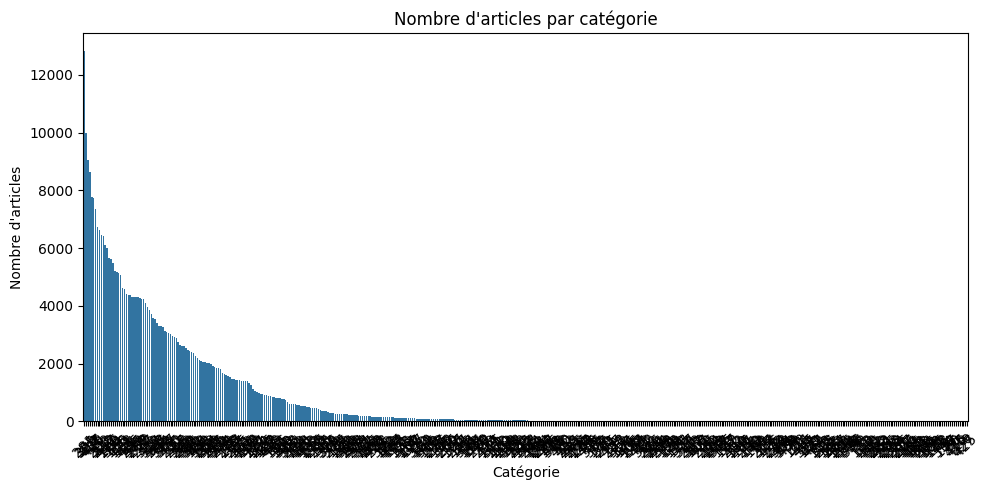

In [9]:
# Nombre d’articles par "category_id"
plt.figure(figsize=(10, 5))
sns.countplot(data=article, x="category_id", order=article["category_id"].value_counts().index)
plt.title("Nombre d'articles par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45) # reste ilisible
plt.tight_layout()
plt.show()

In [13]:
# Top 10 catégories par nombre d'articles
top_10_categories = article['category_id'].value_counts().head(10)



In [15]:
top_10_categories

category_id
281    12817
375    10005
399     9049
412     8648
431     7759
428     7731
26      7343
7       6726
299     6634
301     6446
Name: count, dtype: int64

C:\Users\chris\AppData\Local\Temp\ipykernel_16496\3658644692.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_categories.index, y=top_10_categories.values, order=top_10_categories.index, palette='viridis')


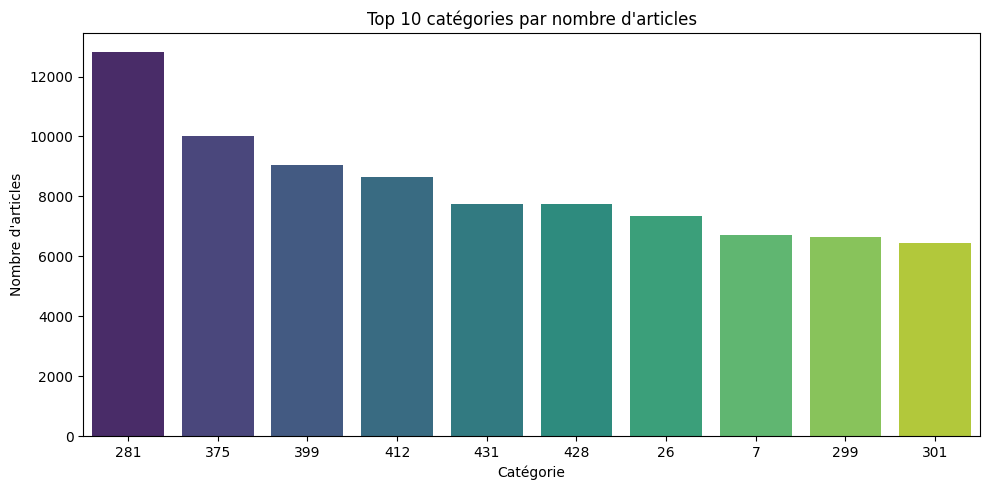

category_id
281    12817
375    10005
399     9049
412     8648
431     7759
428     7731
26      7343
7       6726
299     6634
301     6446
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_categories.index, y=top_10_categories.values, order=top_10_categories.index, palette='viridis')
plt.title("Top 10 catégories par nombre d'articles")
plt.xlabel("Catégorie")
plt.ylabel("Nombre d'articles")
plt.tight_layout()
plt.show()

print(top_10_categories)

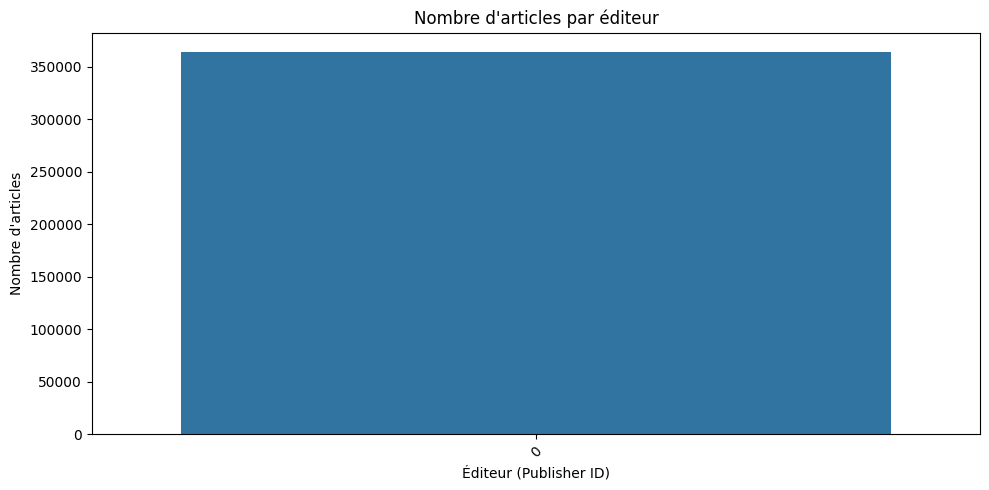

In [10]:
# Nombre d’articles par "publisher_id"
plt.figure(figsize=(10, 5))
sns.countplot(data=article, x="publisher_id", order=article["publisher_id"].value_counts().index)
plt.title("Nombre d'articles par éditeur")
plt.xlabel("Éditeur (Publisher ID)")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

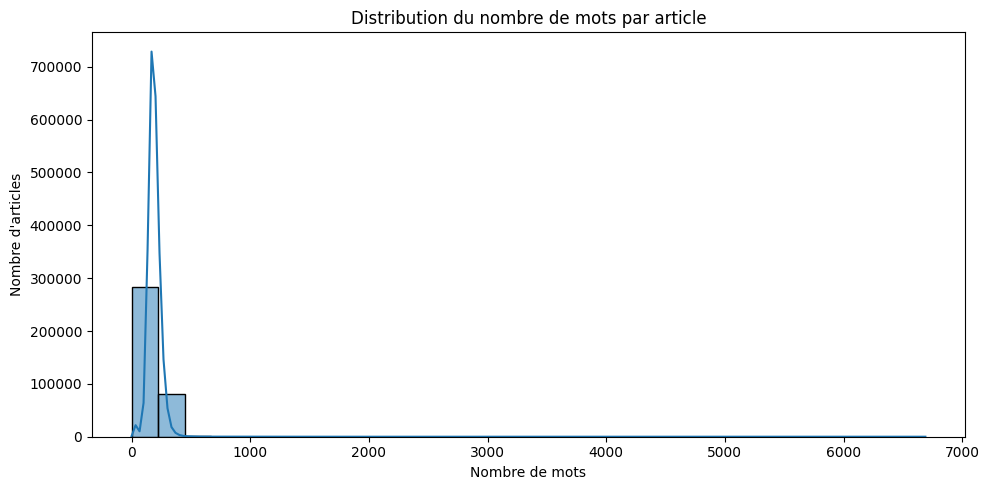

In [11]:
# Distribution du nombre de mots par article (words_count)
plt.figure(figsize=(10, 5))
sns.histplot(article["words_count"], bins=30, kde=True)
plt.title("Distribution du nombre de mots par article")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d'articles")
plt.tight_layout()
plt.show()

### Data handling & user profile creation

In [12]:
import glob

In [13]:
#Concaténatiopn des ficvhiers de clics
clicks_files = glob.glob('clicks/clicks_hour_*.csv')
print(f"{len(clicks_files)} fichiers trouvés")

clicks_df = pd.concat(
    (pd.read_csv(f) for f in clicks_files),
    ignore_index=True
)
print("Shape totale des clics :", clicks_df.shape)

385 fichiers trouvés
Shape totale des clics : (2988181, 12)


In [14]:
# Normalisation L2 
from sklearn.preprocessing import normalize
embeddings_norm = normalize(article_embedding, axis=1)

In [15]:
# def build_user_profile(user_id, clicks_df, embeddings_norm):
#     """Retourne le vecteur profil (moyenne normalisée) d'un utilisateur
#     et la liste des articles déjà vus."""
#     user_clicks = clicks_df[clicks_df['user_id'] == user_id].sort_values('click_timestamp')
#     seen_articles = user_clicks['click_article_id'].unique()

#     if len(seen_articles) == 0:
#         return None, seen_articles

#     profile = embeddings_norm[seen_articles].mean(axis=0)
#     profile = profile / np.linalg.norm(profile) # dEUXIEME NORAMLKISATION APR7S LA MOYENNE
#     return profile, seen_articles

In [16]:
print(clicks_df['click_article_id'].dtype)
print(clicks_df['click_article_id'].isna().sum())

object
0


In [17]:
# Construction du profil content-based d'un utilisateur à partir de son historique de clics.
# Sélection des clics de l'utilisateur et tri chronologique.
# Récupération des identifiants uniques des articles déjà consultés.
# Calcul de la moyenne des embeddings de ces articles pour résumer ses préférences.
#Normalisation du profil afin de pouvoir comparer ce vecteur à tous les articles par similarité cosinus.

def build_user_profile(user_id, clicks_df, embeddings_norm):
    user_clicks = clicks_df[clicks_df['user_id'] == user_id].sort_values('click_timestamp')
    seen_articles = user_clicks['click_article_id'].dropna().astype(int).unique()

    if len(seen_articles) == 0:
        return None, seen_articles

    profile = embeddings_norm[seen_articles].mean(axis=0)
    profile = profile / np.linalg.norm(profile)
    return profile, seen_articles

In [18]:
#évite que click_article_id soit interprété comme un float a cause ndes val manquantes
dtype_clicks = {
    'user_id': 'int64',
    'click_article_id': 'int64',
    'click_timestamp': 'int64',
}

clicks_df = pd.concat(
    (pd.read_csv(f, dtype=dtype_clicks) for f in clicks_files),
    ignore_index=True
)

### Méthode Content-Based

In [19]:
# construit le profil de l'utilisateur puis compare ce profil à l'embedding de chaque
# article du catalogue. Les articles les plus proches du profil sont considérés comme les plus pertinents.
# Les contenus déjà consultés sont exclus afin de ne proposer que de nouveaux articles.

def recommend_content_based(user_id, clicks_df, embeddings_norm, n=5):
    profile, seen_articles = build_user_profile(user_id, clicks_df, embeddings_norm)
    if profile is None:
        return []

    # Similarité cosinus = produit scalaire car les vecteurs sont normalisés
    similarities = embeddings_norm @ profile

    # On exclut les articles déjà lus
    similarities[seen_articles] = -1

    top_n = np.argsort(similarities)[::-1][:n]
    return list(zip(top_n, similarities[top_n]))

# Exemple
recos = recommend_content_based(user_id=2, clicks_df=clicks_df, embeddings_norm=embeddings_norm, n=5)
for article_id, score in recos:
    print(f"Article {article_id} — similarité {score:.3f}")

Article 31920 — similarité 0.839
Article 31400 — similarité 0.839
Article 25856 — similarité 0.837
Article 31927 — similarité 0.833
Article 30847 — similarité 0.830


In [20]:
#pca pour le content base voir si amélioration 

### Méthode Content-Based avec PCA

In [21]:
from sklearn.decomposition import PCA

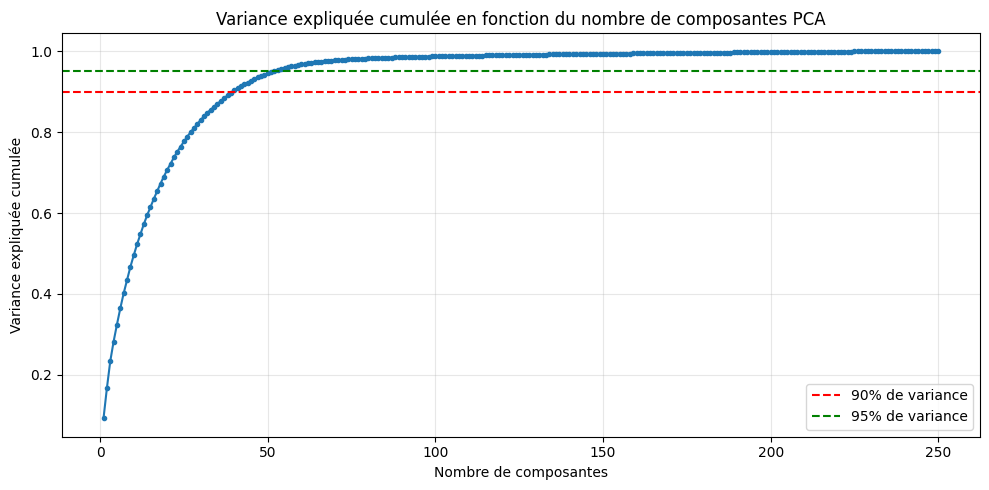

In [22]:
# PCA avec toutes les composantes pour observer la courbe complète
pca_full = PCA(random_state=42)
pca_full.fit(article_embedding)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, marker='.', linestyle='-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% de variance')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée en fonction du nombre de composantes PCA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
n_90 = np.argmax(variance_cumulee >= 0.90) + 1
n_95 = np.argmax(variance_cumulee >= 0.95) + 1

print(f"Nombre de composantes pour 90% de variance : {n_90}")
print(f"Nombre de composantes pour 95% de variance : {n_95}")

Nombre de composantes pour 90% de variance : 40
Nombre de composantes pour 95% de variance : 52


In [24]:
# Réduction de dimension par PCA sur les embeddings originaux
n_components = 52  # à ajuster selon la variance expliquée souhaitée
pca = PCA(n_components=n_components, random_state=42)
embeddings_pca = pca.fit_transform(article_embedding)

print(f"Variance expliquée cumulée avec {n_components} composantes : {pca.explained_variance_ratio_.sum():.3f}")

Variance expliquée cumulée avec 52 composantes : 0.951


In [25]:
# Renormalisation L2 des embeddings réduits 
embeddings_pca_norm = normalize(embeddings_pca, axis=1)

In [26]:
# Recommandation avec les embeddings PCA, mêmes fonctions réutilisées
recos_pca = recommend_content_based(user_id=2, clicks_df=clicks_df, embeddings_norm=embeddings_pca_norm, n=5)

print("Recommandations après PCA :")
for article_id, score in recos_pca:
    print(f"Article {article_id} — similarité {score:.3f}")

Recommandations après PCA :
Article 31400 — similarité 0.829
Article 22461 — similarité 0.810
Article 31920 — similarité 0.808
Article 31927 — similarité 0.802
Article 28911 — similarité 0.796


In [27]:
# Comparaison directe des deux jeux de recommandations
recos_original = recommend_content_based(user_id=2, clicks_df=clicks_df, embeddings_norm=embeddings_norm, n=5)

ids_original = [a for a, _ in recos_original]
ids_pca = [a for a, _ in recos_pca]

print("Articles communs :", set(ids_original) & set(ids_pca))
print("Articles différents avant pca :", set(ids_original) - set(ids_pca))
print("Articles différents après pca :", set(ids_pca) - set(ids_original))

Articles communs : {np.int64(31400), np.int64(31920), np.int64(31927)}
Articles différents avant pca : {np.int64(25856), np.int64(30847)}
Articles différents après pca : {np.int64(22461), np.int64(28911)}


### Méthode de Collaborative Filtering

In [28]:
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, cross_validate
import random

random.seed(42)

interactions_pos = clicks_df[['user_id', 'click_article_id']].drop_duplicates().copy()
interactions_pos['rating'] = 1

print(f"{len(interactions_pos)} interactions positives")


2950710 interactions positives


In [29]:
all_article_ids = set(article['article_id'].unique())
negative_samples = []

n_neg_per_user = 5  # ratio négatifs/positifs, à ajuster

for user_id, group in interactions_pos.groupby('user_id'):
    seen = set(group['click_article_id'])
    not_seen = list(all_article_ids - seen)

    n_samples = min(n_neg_per_user * len(seen), len(not_seen))
    sampled = random.sample(not_seen, n_samples)

    for article_id in sampled:
        negative_samples.append({'user_id': user_id, 'click_article_id': article_id, 'rating': 0})

negatives_df = pd.DataFrame(negative_samples)
print(f"{len(negatives_df)} interactions négatives générées")

14753550 interactions négatives générées


In [30]:
interactions_full = pd.concat([interactions_pos, negatives_df], ignore_index=True)
print(f"{len(interactions_full)} interactions au total")

17704260 interactions au total


In [31]:
reader = Reader(rating_scale=(0, 1))
data = Dataset.load_from_df(interactions_full[['user_id', 'click_article_id', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [32]:
algo = SVD(n_factors=50, random_state=42)
algo.fit(trainset)

predictions = algo.test(testset)
print("RMSE :", accuracy.rmse(predictions))


RMSE: 0.1302
RMSE : 0.13019722708162512


In [ ]:
import pickle
#Model léger pour déploiement sur azure car le svd complet trop lourd au cold start fait crash azure
svd_light = {
    "global_mean": float(algo.trainset.global_mean),
    "bu": algo.bu.astype(np.float32),
    "bi": algo.bi.astype(np.float32),
    "pu": algo.pu.astype(np.float32),
    "qi": algo.qi.astype(np.float32),
    "raw2inner_user": dict(algo.trainset._raw2inner_id_users),
    "raw2inner_item": dict(algo.trainset._raw2inner_id_items),
}

with open("models/svd_model_light.pkl", "wb") as f:
    pickle.dump(svd_light, f, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
#Vérification rapide de la taille du modèle léger pour s'assurer qu'il est bien plus petit que le modèle complet.
import os
print(
    os.path.getsize("models/svd_model_light.pkl") / (1024**2),
    "Mo"
)

139.69734477996826 Mo


: 

In [33]:
cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.1305  0.1306  0.1300  0.1299  0.1305  0.1303  0.0003  
MAE (testset)     0.0546  0.0546  0.0545  0.0544  0.0546  0.0545  0.0001  
Fit time          163.93  176.41  183.31  156.03  161.32  168.20  10.09   
Test time         70.64   247.79  349.88  726.40  151.70  309.28  228.56  


In [34]:
def recommend_surprise(user_id, algo, interactions_full, article_ids, n=5):
    seen = set(interactions_full.loc[
        (interactions_full['user_id'] == user_id) & (interactions_full['rating'] == 1),
        'click_article_id'
    ])
    candidates = [a for a in article_ids if a not in seen]

    predictions = [(article_id, algo.predict(user_id, article_id).est) for article_id in candidates]
    predictions.sort(key=lambda x: x[1], reverse=True)

    return predictions[:n]

In [35]:
recos_svd = recommend_surprise(2, algo, interactions_full, article['article_id'].unique(), n=5)

print("\nRecommandations SVD (surprise) :")
for article_id, score in recos_svd:
    print(f"Article {article_id} — score prédit {score:.3f}")


Recommandations SVD (surprise) :
Article 158535 — score prédit 1.000
Article 212165 — score prédit 1.000
Article 87234 — score prédit 0.993
Article 96986 — score prédit 0.991
Article 62463 — score prédit 0.985


In [ ]:
ids_svd = [a for a, _ in recos_svd]

print("\nCommuns SVD & content-based (original) :", set(ids_original) & set(ids_svd))
print("Communs SVD & content-based (PCA) :", set(ids_pca) & set(ids_svd))
print("Uniquement en SVD :", set(ids_svd) - set(ids_original) - set(ids_pca))


Communs SVD ∩ content-based (original) : set()
Communs SVD ∩ content-based (PCA) : set()
Uniquement en SVD : {np.int64(87234), np.int64(212165), np.int64(158535), np.int64(96986), np.int64(62463)}


In [37]:
import pickle
import os

os.makedirs('models', exist_ok=True)

with open('models/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

with open('models/svd_model.pkl', 'wb') as f:
    pickle.dump(algo, f)

with open('models/embeddings_pca_norm.pkl', 'wb') as f:
    pickle.dump(embeddings_pca_norm, f)

print("Modèles et embeddings sauvegardés dans le dossier 'models/' :")
print(" - models/pca_model.pkl")
print(" - models/svd_model.pkl")
print(" - models/embeddings_pca_norm.pkl")

Modèles et embeddings sauvegardés dans le dossier 'models/' :
 - models/pca_model.pkl
 - models/svd_model.pkl
 - models/embeddings_pca_norm.pkl


In [38]:
# Export des données nécessaires au déploiement (Azure Function)
import pickle

# Articles déjà vus par utilisateur (rating == 1), utilisé pour exclure les articles déjà consultés
seen_by_user = (
    interactions_full[interactions_full['rating'] == 1]
    .groupby('user_id')['click_article_id']
    .apply(set)
    .to_dict()
)

# Liste de tous les articles candidats
article_ids_list = list(article['article_id'].unique())

with open('models/seen_articles.pkl', 'wb') as f:
    pickle.dump(seen_by_user, f)

with open('models/article_ids.pkl', 'wb') as f:
    pickle.dump(article_ids_list, f)

print("Données de déploiement sauvegardées :")
print(" - models/seen_articles.pkl")
print(" - models/article_ids.pkl")


Données de déploiement sauvegardées :
 - models/seen_articles.pkl
 - models/article_ids.pkl
